In [47]:
import solver, validator
import file_manager as fm
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

importlib.reload(solver)
importlib.reload(validator)
importlib.reload(fm)
C1Result = fm.C1Result

In [49]:
results = [
    C1Result.load(path)
    for path in Path("seeds").glob("*.npz")
]

table = pd.DataFrame(result.row() for result in results)
table = table.drop(columns=["file", "ode_nfev", "ode_njev", "ode_nlu", "ode_message"], errors="ignore")
table = table.sort_values(["eM", "q"])
display(table)

,eM,q,p_amp,p_phase,charge_residual,Re_Phi_U_1,Im_Phi_U_1,residual_norm,max_residual,inf_xi,...,max_domega,min_r,rV_0,rU_0,interpolated_min_focusing,matching_ok,xi_ok,rU_ok,finite,valid
13,20.0,1.0,4,4,2.286302e-09,-1.432498e-07,2.912779e-07,3.246052e-07,2.912779e-07,0.004872,...,5.744561,0.004872,3.322064,-0.075254,1.167172e-07,True,True,True,True,True
1,25.0,1.0,4,4,1.026935e-09,-3.096050e-07,2.212244e-07,3.805215e-07,3.096050e-07,0.004719,...,4.533096,0.004719,3.269392,-0.076467,1.139125e-07,True,True,True,True,True
11,30.0,1.0,4,4,1.223877e-09,-4.101806e-07,1.285060e-07,4.298411e-07,4.101806e-07,0.005290,...,3.708467,0.005290,3.245909,-0.077020,1.086917e-07,True,True,True,True,True
3,35.0,1.0,4,4,-7.304795e-09,-4.647442e-07,3.803055e-08,4.663549e-07,4.647442e-07,0.005365,...,3.119567,0.005365,3.235203,-0.077275,1.036752e-07,True,True,True,True,True
5,40.0,1.0,4,4,4.983163e-10,-5.105444e-07,-4.689268e-08,5.126936e-07,5.105444e-07,0.005360,...,2.675717,0.005360,3.231715,-0.077358,9.813280e-08,True,True,True,True,True
8,45.0,1.0,4,4,6.034718e-09,-5.475091e-07,-1.083369e-07,5.581572e-07,5.475091e-07,0.004364,...,2.331539,0.004364,3.233546,-0.077315,9.274809e-08,True,True,True,True,True
6,50.0,1.0,4,4,4.932548e-09,-5.812034e-07,-1.727531e-07,6.063542e-07,5.812034e-07,0.004233,...,2.057247,0.004233,3.234420,-0.077294,8.836957e-08,True,True,True,True,True
7,55.0,1.0,4,4,-1.581587e-10,-6.189946e-07,-2.339301e-07,6.617233e-07,6.189946e-07,0.004209,...,1.841783,0.004209,3.237315,-0.077224,8.293546e-08,True,True,True,True,True
2,60.0,1.0,4,4,-3.248610e-09,-6.489083e-07,-2.885444e-07,7.101763e-07,6.489083e-07,0.004247,...,1.655311,0.004247,3.238224,-0.077203,8.004216e-08,True,True,True,True,True
10,65.0,1.0,4,4,-6.866117e-09,-6.710174e-07,-3.384856e-07,7.515876e-07,6.710174e-07,0.000615,...,1.502568,0.000615,3.249438,-0.076936,7.525013e-08,True,True,True,True,True


In [50]:
for result in results:
    result.evaluate(
        solver.tanh_ansatz,
        solver.omega_domega,
        solver.rplus_and_Qtarget,
        n_grid=10001,
        n_profile=10001,
    )

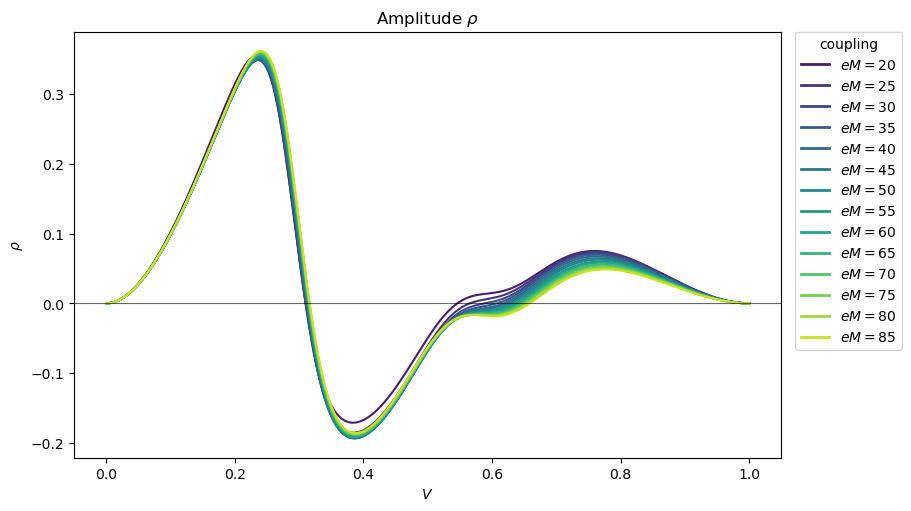

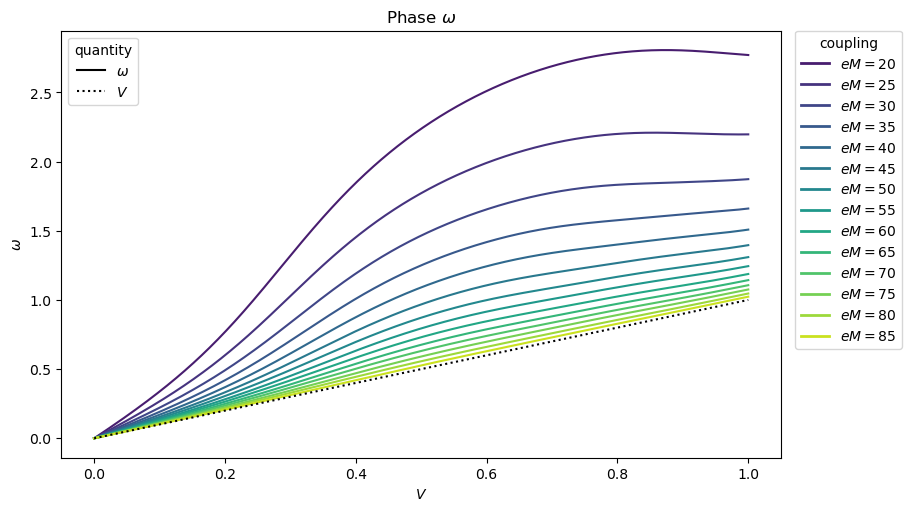

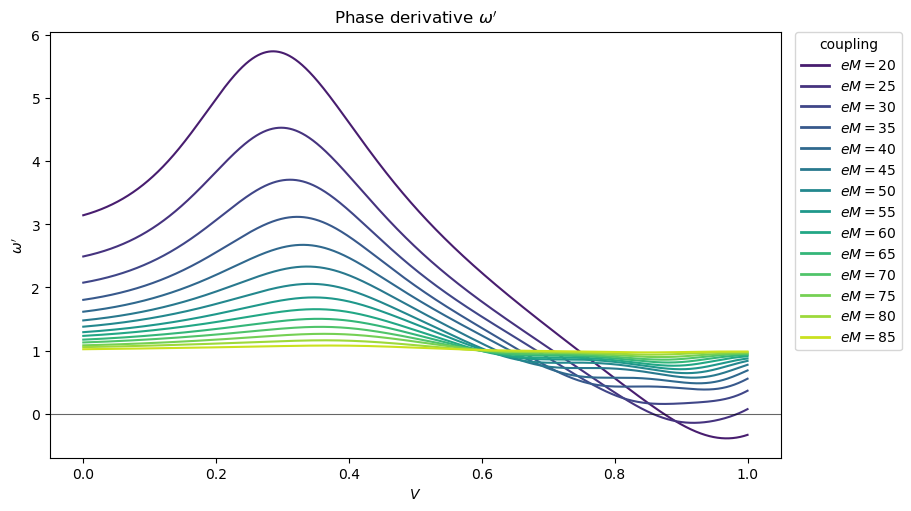

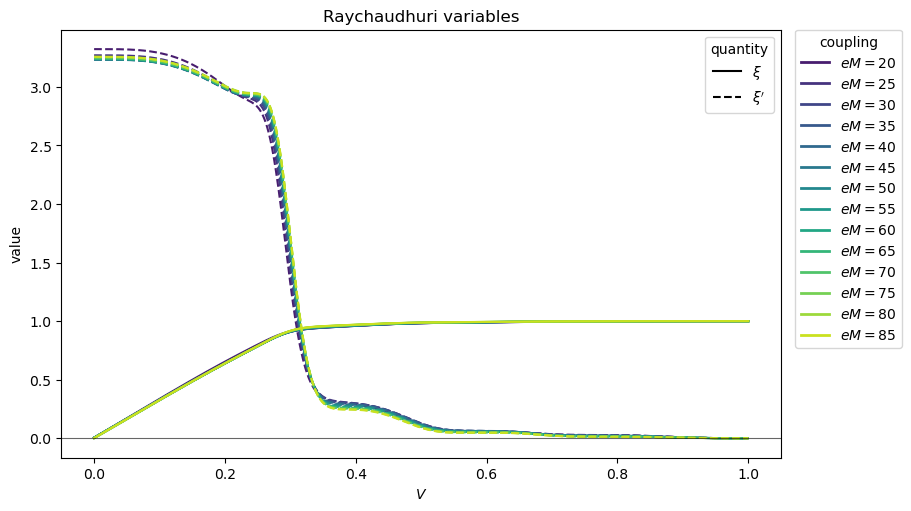

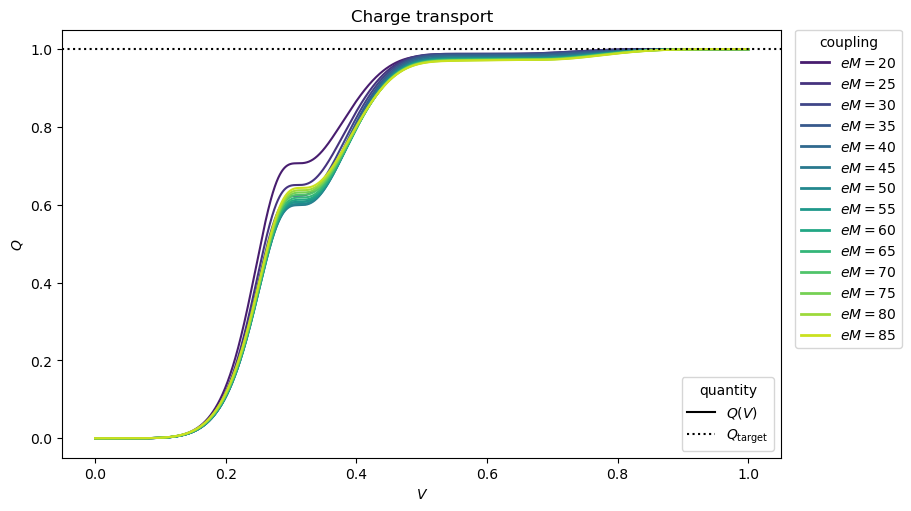

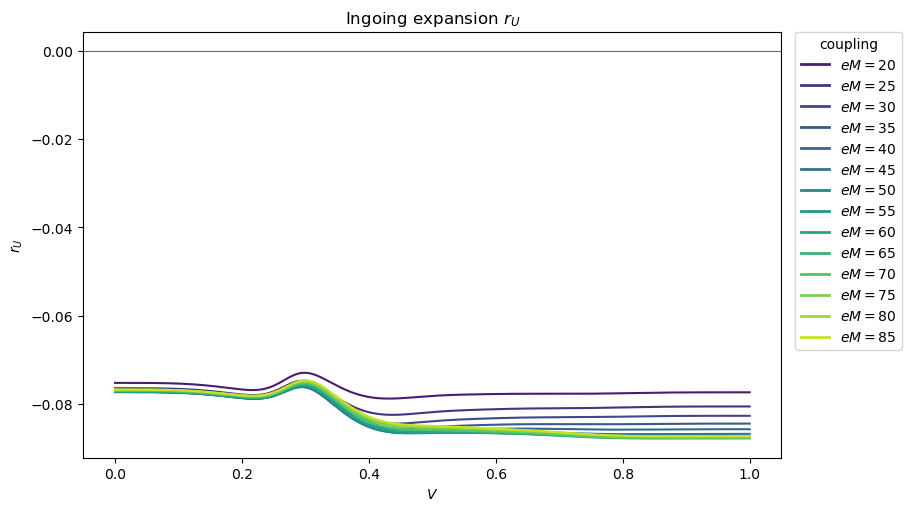

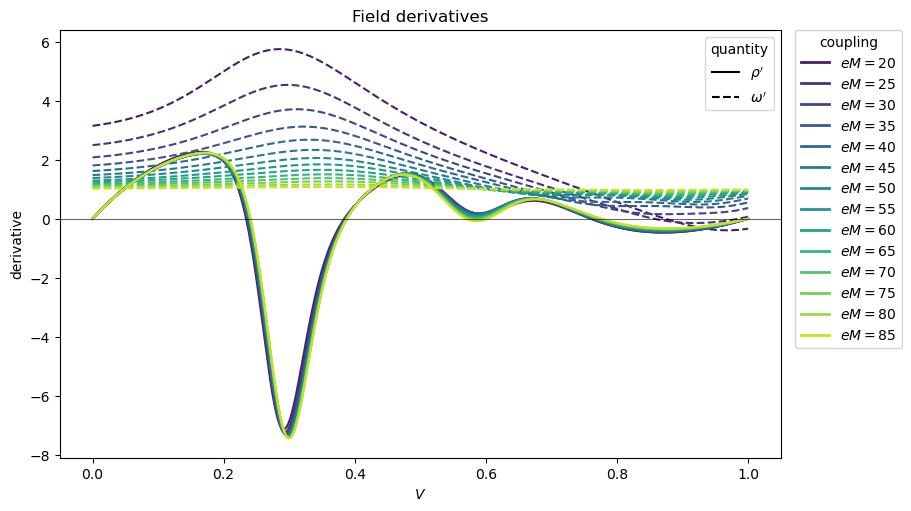

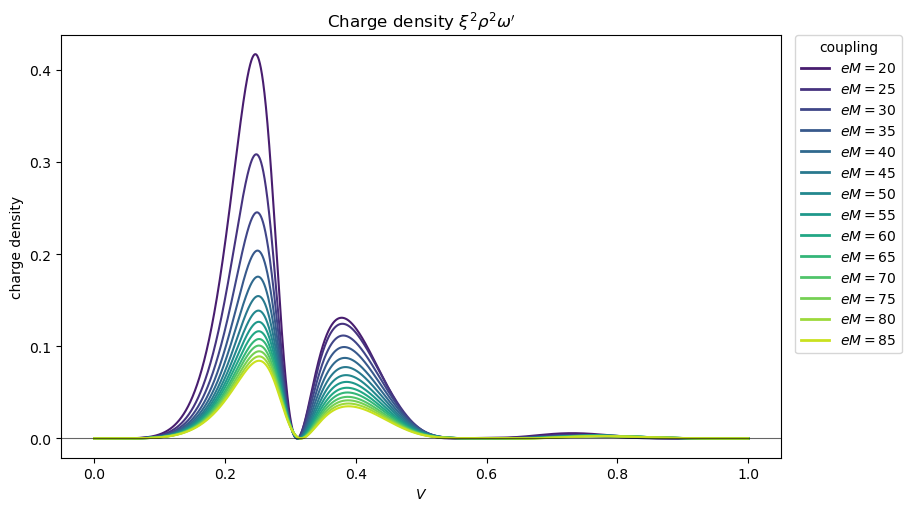

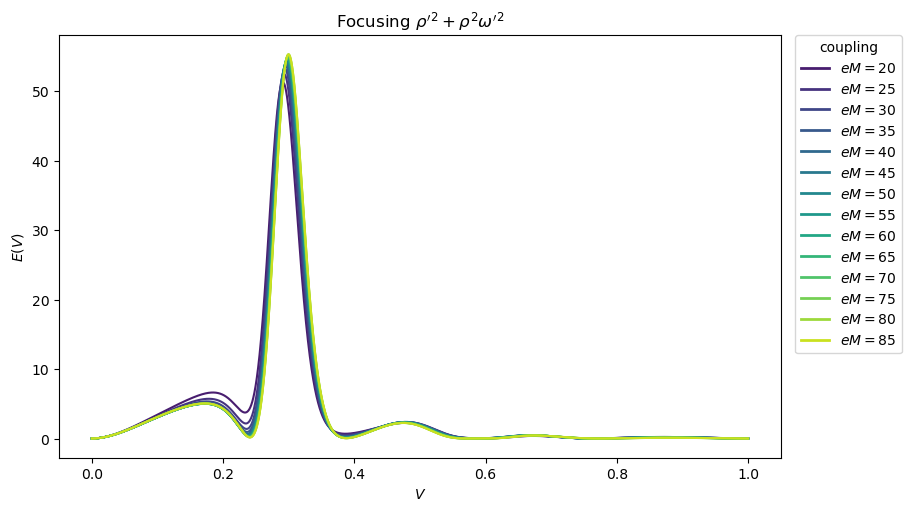

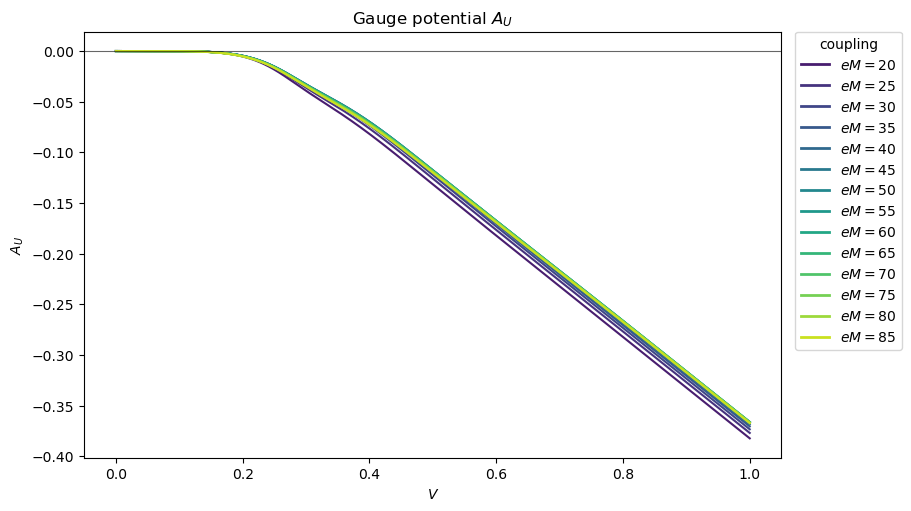

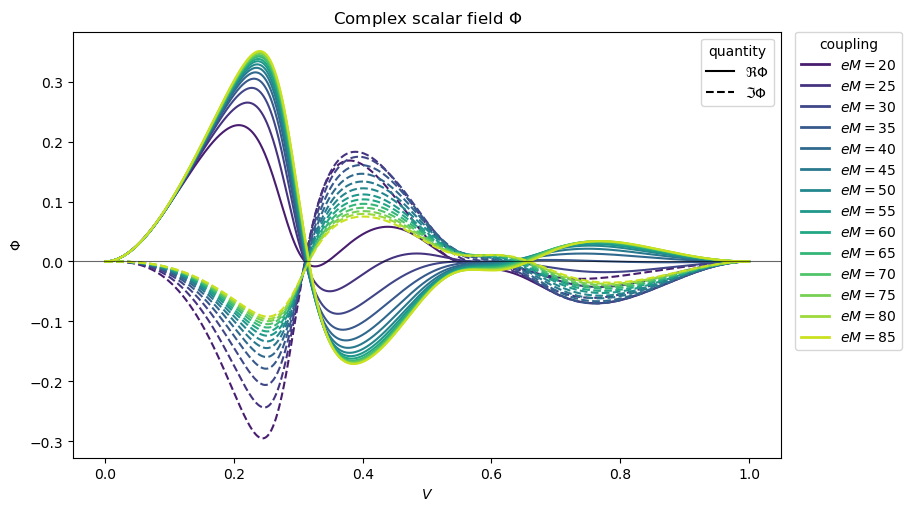

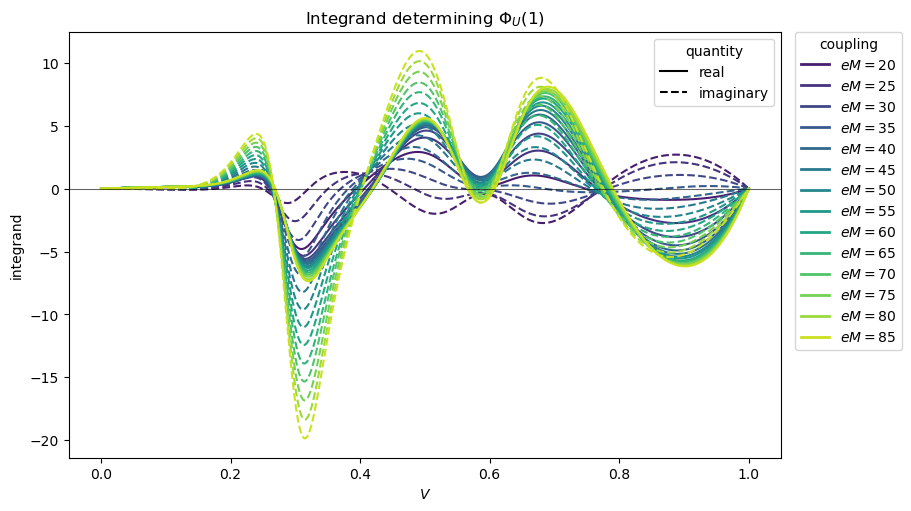

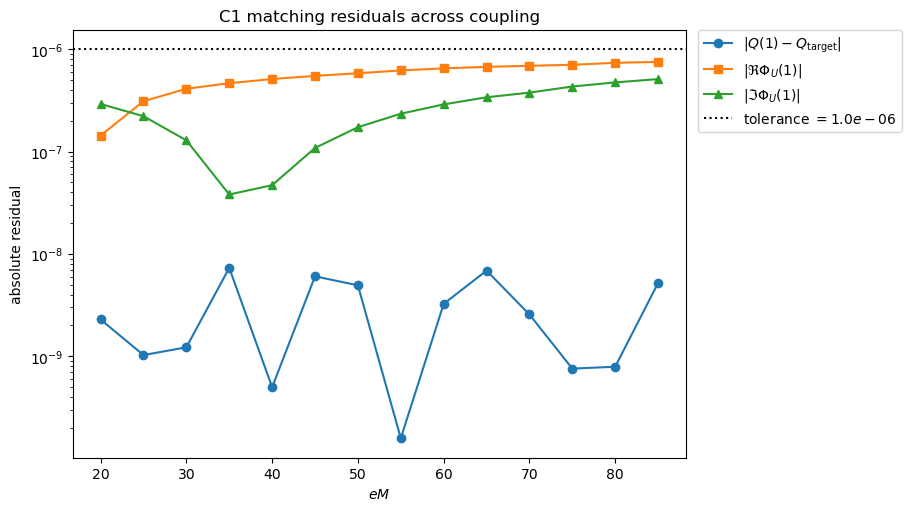

In [51]:
comparison_figures = validator.plot_C1_comparison_suite(results, residual_tolerance=1e-6)